You can just click **Runtime → Run all** to try the demo.

# Module 4: Autoencoders & Compression - A Responsible Perspective

In this module, we introduce the **autoencoders**. They are widely used as a foundational tool for a variety of machine learning purposes. They are simple but powerful, and their structure has influenced more advanced models. In this module, we explore how autoencoders work by watching them reconstruct images, compress them, and clean them up through denoising.


In [32]:
#@title system-setup {display-mode: "form"}
#install required packages
#!pip install fsspec

#import required packages
from PIL import Image
import os
import fsspec
import numpy as np
import requests
from io import BytesIO
import tensorflow as tf
import pandas as pd

import matplotlib.pyplot as plt

from tensorflow.keras import Input
from tensorflow.keras.models import load_model, Model

import pickle

import warnings
warnings.filterwarnings('ignore')

## The STL-10 Dataset
[The STL-10 dataset](http://cs.stanford.edu/~acoates/stl10) is a benchmark image dataset developed for research in unsupervised and semi-supervised learning. It contains 96×96 color images across 10 object categories (such as airplanes, birds, and cars), and is derived from a subset of the ImageNet dataset—a large, publicly available collection of images organized by object categories.

In this project, we use only the training and test image sets (not the labels) to demonstrate how autoencoders perform image compression, reconstruction, and denoising.

In [7]:
#@title Load the STL-10 Dataset from Github repo {display-mode: "form"}

# Base URL (change this to your actual repo and path)
base_url = "https://raw.githubusercontent.com/WeihaoGe1009/ai-history-for-ip-scholars/main/04_autoencoders/"

# Auto-generate URLs
image_urls = [f"{base_url}data/autoencoder_test_example/image_{i:02d}.jpg" for i in range(10)]

def load_and_preprocess(urls, target_size=(64, 64)):
    images = []
    for url in urls:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        #img = Image.open(url).convert("RGB")
        img = img.resize(target_size)
        img_array = np.array(img) / 255.0  # normalize to [0, 1]
        images.append(img_array)
    return np.array(images)

x_data = load_and_preprocess(image_urls)

print("Image batch shape:", x_data.shape)  # Should be (10, 64, 64, 3)


Image batch shape: (10, 64, 64, 3)


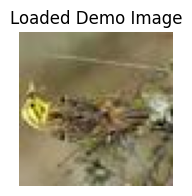

In [8]:
#@title show one image from the STL-10 data set {display-mode: "form"}

import matplotlib.pyplot as plt

# Show the first image (index 0)
plt.figure(figsize=(2, 2))
plt.imshow(x_data[0])
plt.title("Loaded Demo Image")
plt.axis("off")
plt.show()


## Autoencoder structure

Our first model is a simple convolutional autoencoder that learns to compress and reconstruct input images. The encoder uses a series of Conv2D layers with stride=2 to reduce spatial resolution, while the decoder uses Conv2DTranspose layers to reconstruct the image.

In [12]:
#@title load a pre-trained autoencoder {display-mode: "form"}

model_dir = 'models/'
model_name = 'model_strided_autoencoder.keras'
model_url = base_url + model_dir + model_name

!wget {model_url} -O {model_name}
model = load_model(model_name)
model.summary()

https://raw.githubusercontent.com/WeihaoGe1009/ai-history-for-ip-scholars/main/04_autoencoders/models/model_strided_autoencoder.keras
--2026-04-02 15:41:42--  https://raw.githubusercontent.com/WeihaoGe1009/ai-history-for-ip-scholars/main/04_autoencoders/models/model_strided_autoencoder.keras
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 166004 (162K) [application/octet-stream]
Saving to: ‘model_strided_autoencoder.keras’

model_strided_autoe 100%[===================>] 162.11K  --.-KB/s    in 0.01s   

2026-04-02 15:41:43 (11.3 MB/s) - ‘model_strided_autoencoder.keras’ saved [166004/166004]



Model: "strided"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 48, 48, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 96, 96, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,083 (129.23 KB)

 Trainable params: 11,027 (43.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,056 (86.16 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


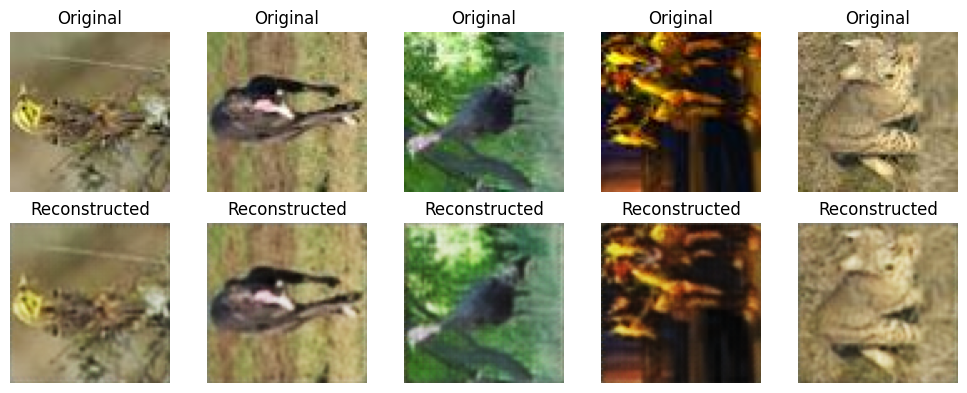

In [13]:
#@title Output of Autoencoder and Original Input Image {display-mode: "form"}

x_resized = tf.image.resize(x_data[:10], [96, 96])  # Resize to (96, 96)
decoded_imgs = model.predict(x_resized)

n = 5  # how many digits we will display
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_data[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.tight_layout()
plt.show()


comment: the images are upsettingly similar. Let's see what happens "inside" the autoencoder

In [14]:
#@title Under the Hood - Encoding and Decoding {display-mode: "form"}

def plot_encoder_decoder_activations(input_image, activations, custom_labels, maps_per_layer=4):
    input_image = np.squeeze(input_image)
    input_image_disp = input_image if input_image.shape[-1] == 3 else input_image[..., 0]

    n_layers = len(activations)
    fig, axes = plt.subplots(n_layers, maps_per_layer + 1, figsize=((maps_per_layer + 1) * 2, n_layers * 2))

    for row in range(n_layers):
        # Show input image on the left
        axes[row, 0].imshow(input_image_disp)
        axes[row, 0].axis("off")

        # Add layer name manually as a text label
        axes[row, 0].text(
            -0.25, 0.5, custom_labels[row],
            transform=axes[row, 0].transAxes,
            fontsize=10,
            rotation=0,
            va='center',
            ha='right'
        )

        # Activation maps for this layer
        activation = activations[row][0]  # shape (H, W, channels)
        n_maps = min(maps_per_layer, activation.shape[-1])
        for col in range(n_maps):
            ax = axes[row, col + 1]
            act_img = activation[:, :, col]
            act_img -= act_img.mean()
            act_img /= (act_img.std() + 1e-5)
            act_img *= 64
            act_img += 128
            act_img = np.clip(act_img, 0, 255).astype("uint8")
            ax.imshow(act_img, cmap="gray")
            ax.axis("off")

        for col in range(n_maps + 1, maps_per_layer + 1):
            axes[row, col].axis("off")

    # Add readable custom y-axis labels
    for row, label in enumerate(custom_labels):
        axes[row, 0].set_ylabel(label, rotation=0, labelpad=60, fontsize=12, va='center', ha='right', wrap=True)

    plt.tight_layout(rect=[0.15, 0, 1, 1])
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


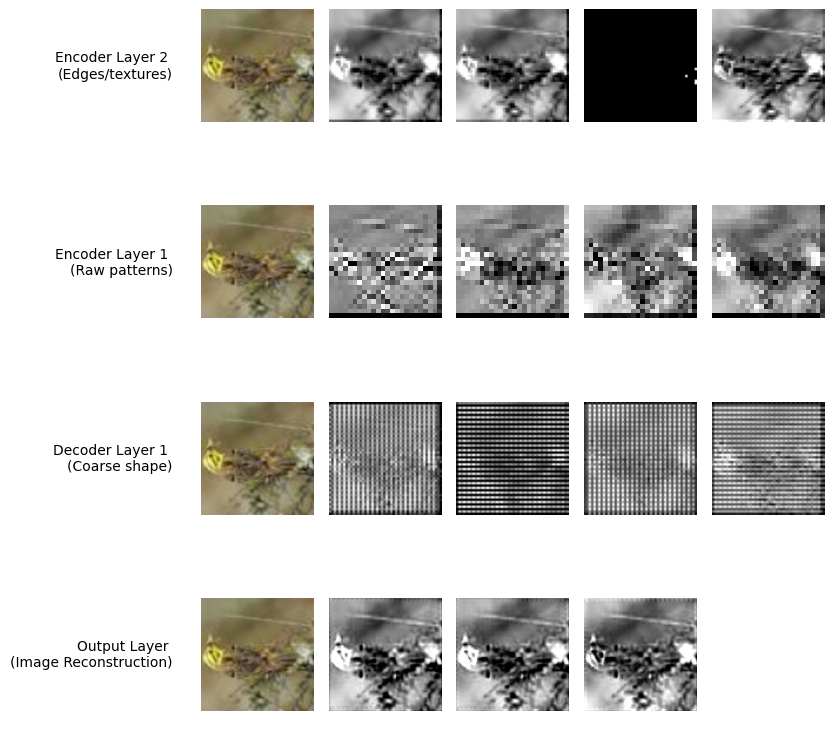

In [15]:
#@title Layers and patterns learnt {display-mode: "form"}
# Select encoder + reversed decoder layers
selected_layers = [
    model.get_layer('conv2d_9'),         # Encoder Layer 1
    model.get_layer('conv2d_10'),        # Encoder Layer 2
    model.get_layer('conv2d_transpose'),   # Decoder Layer 1 (Coarse shape)
    model.get_layer('conv2d_transpose_1'),  # Decoder Layer 2 (Detail fill-in)
]


activation_model = Model(inputs=model.input, outputs=[layer.output for layer in selected_layers])
activations = activation_model.predict(np.expand_dims(x_resized[0], axis=0))

custom_labels = [
    "Encoder Layer 2 \n(Edges/textures)",
    "Encoder Layer 1 \n(Raw patterns)",
    "Decoder Layer 1 \n(Coarse shape)",
    "Output Layer \n(Image Reconstruction)",
]


plot_encoder_decoder_activations(x_resized[0], activations, custom_labels, maps_per_layer=4)


We can see that the neurons in the **Encoder Layers** "learn" the edges and textures, as well as more abstract features. In the **Decoder Layers**, the code reconstructs the images by "adding" up the encoded information according to which neuron is activated.

## Compression
One of the most important application of autoencoder is to compress the images, which enables efficient storage

In [16]:
#@title Calculate Compression Ratio {display-mode: "form"}

# Get the full model input shape
input_shape = model.input_shape[1:]  # Exclude batch dim
input_size = np.prod(input_shape)

# Create a model that outputs the encoder's final layer
# Assuming last encoder layer is model.layers[4] (update if needed)
encoder_layer = model.layers[2]
encoder_model = Model(inputs=model.input, outputs=encoder_layer.output)

# Run one sample image through the encoder
sample_image = x_resized[0:1]  # Keep batch dimension
encoded = encoder_model.predict(sample_image)
encoded_shape = encoded.shape[1:]  # Exclude batch dim
encoded_size = np.prod(encoded_shape)

# Compute compression ratio
compression_ratio = input_size / encoded_size

# Print result
print(f"Input shape: {input_shape}, size: {input_size}")
print(f"Encoded shape: {encoded_shape}, size: {encoded_size}")
print(f"Compression ratio: {compression_ratio:.2f}x")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Input shape: (96, 96, 3), size: 27648
Encoded shape: (24, 24, 16), size: 9216
Compression ratio: 3.00x


from the information above, we know that the image is compressed to around 1/3 of the original size. In real practice, we further extract something called **"Principal Component (PC)"** to maintain the major features in the encoded layer. Now we can load and check how the image is restored from the PCs.

In [21]:
#@title Load pre-extracted Principle Components {display-mode: "form"}
pca_latent_url = base_url+'models/pca_latents.npy'
pca_model_url = base_url+'models/pca_model.pkl'
encoded_shape_url = base_url + 'models/encoded_shape.npy'
decoder_model_url = base_url + 'models/decoder_model.keras'


os.system(f"wget {pca_latent_url}")
os.system(f"wget {pca_model_url}")
os.system(f"wget {encoded_shape_url}")
os.system(f"wget {decoder_model_url}")

# === Load compressed latent features ===
pca_features = np.load('pca_latents.npy')

# Load PCA object using pickle
with open('pca_model.pkl', "rb") as f:
    pca = pickle.load(f)

# Load encoded shape
encoded_shape = tuple(np.load('encoded_shape.npy'))  # e.g., (24, 24, 16)

# === Inverse PCA to reconstruct encoded layer ===
reconstructed_flat = pca.inverse_transform(pca_features)
reconstructed_encoded = reconstructed_flat.reshape((-1,) + encoded_shape)

# === Load decoder and decode the images ===
decoder = load_model('decoder_model.keras')

https://raw.githubusercontent.com/WeihaoGe1009/ai-history-for-ip-scholars/main/04_autoencoders/models/pca_latents.npy


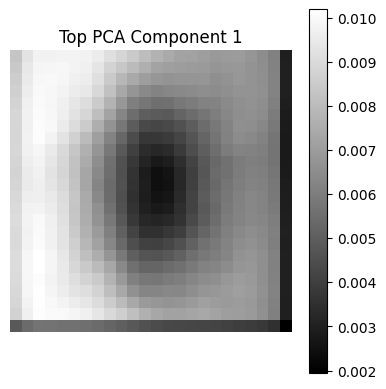

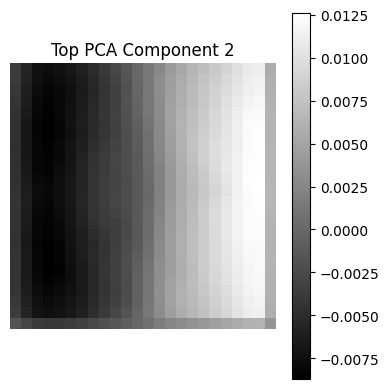

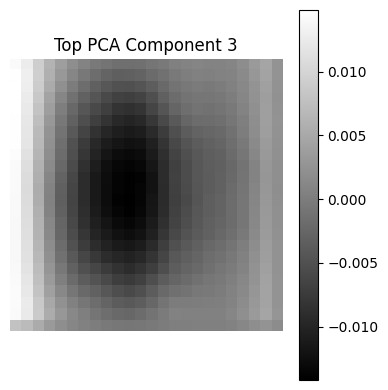

In [22]:
#@title Show the top 3 Principal Components reshaped to encoder output shape {display-mode: "form"}
top_components = pca.components_[:3]  # Each is a 1D array of length 9216
for i, comp in enumerate(top_components):
    plt.figure(figsize=(4, 4))
    plt.imshow(comp.reshape(24, 24, 16).mean(axis=-1), cmap='gray')  # Mean over channels for simplicity
    plt.title(f"Top PCA Component {i+1}")
    plt.axis("off")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


### What do these grayscale heatmaps represent?
Each Principal Component is a "basic direction" that captures a major axis of variation across many encoded images.
To visualize them, we reshape each component (a flat vector of 9,216 numbers) back into the original encoder shape: (24, 24, 16). Then, we take the mean across channels, collapsing it into a (24, 24) image.
These show rough "landscape-like" shapes — like ridges or valleys — that frequently appear in different images’ compressed forms.

**Analogy:**

Think of the encoded image as a mountain range. The Principal Components looks at thousands of such "terrains" and finds the most common slopes. Each top component is a direction along which many images vary — PC1 is a valley, PC2 is a slop to the left, and PC3 is another valley. It is common that PCs might look similar (like PC1 and PC3). This possibly reflects that many STL-10 images tend to have darker features in the middle-right zone. Even though PC1 and PC3 look similar, they still capture slightly different nuances — they got picked because both help explain how STL-10 images tend to vary.

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step


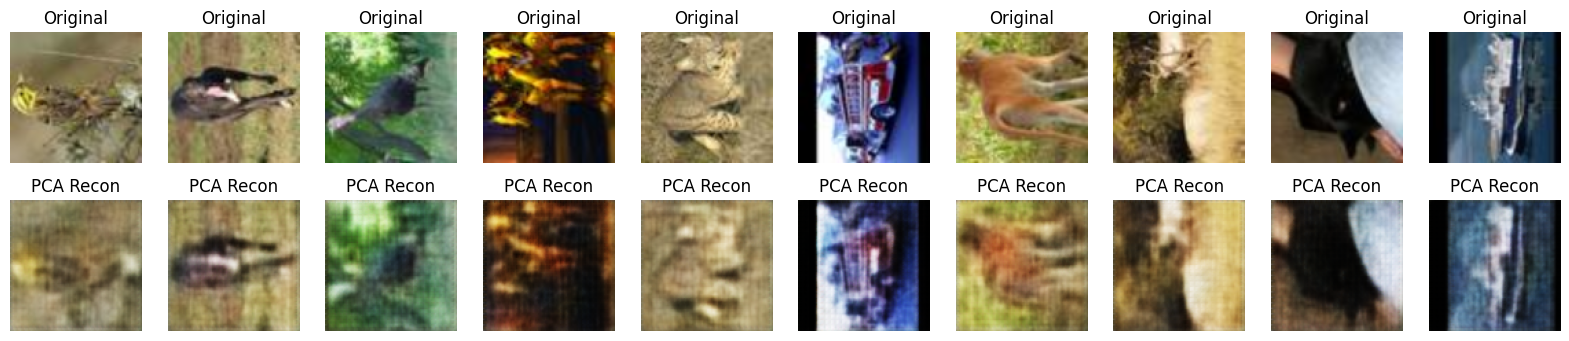

In [23]:
#@title reconstruct images from Principle Components (might take a while) {display-mode: "form"}
decoded_images = decoder.predict(reconstructed_encoded)

# === Display: original vs reconstructed ===
n = min(10, len(decoded_images))
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_resized[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(np.clip(decoded_images[i], 0, 1))
    plt.title("PCA Recon")
    plt.axis("off")
plt.show()

In [24]:
#@title Calculate the Compression Rate from Principal Component {display-mode: "form"}
pca_dict_size = pca_features.shape[1] * encoded_size + encoded_size
pca_code_size = pca_features.shape[1]
pc_size = 1 * pca_code_size + pca_dict_size
print(f"Input shape: {input_shape}, size: {input_size}")
print("PC dimensions:", pc_size)
compression_ratio_pca = input_size / pc_size
print(f"Compression ratio: {compression_ratio_pca:.2f}x")

Input shape: (96, 96, 3), size: 27648
PC dimensions: 3530110
Compression ratio: 0.01x


At first glance, Principal Component doesn't look helpful at all. If we try to compress just one image, the result is actually much larger than the original — more than 100 times the size!

But that’s because this approach stores a shared set of “basic shapes” (the "components") that work across all images. For just one image, we still have to carry the entire set of shared shapes, which dominates the storage.

As we compress more and more images, we reuse that same shared information. Eventually, each image only needs to store a small set of 300 numbers — its unique “blend” of those shared shapes.

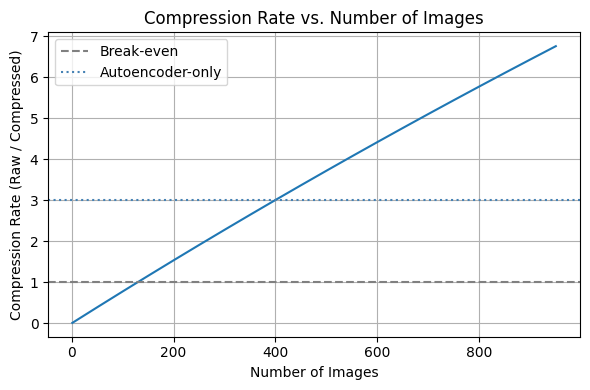

In [25]:
#@title Compression Rate with more images {display-mode: "form"}

N_values = np.arange(1, 1001, 50)
image_size = 96 * 96 * 3
pca_code_size = pca_features.shape[1]
pca_dict_size = pca_features.shape[1] * encoded_size + encoded_size

compression_ratios_pca = (N_values * image_size) / (N_values * pca_code_size + pca_dict_size)

plt.figure(figsize=(6, 4))
plt.plot(N_values, compression_ratios_pca)
plt.title("Compression Rate vs. Number of Images")
plt.xlabel("Number of Images")
plt.ylabel("Compression Rate (Raw / Compressed)")
plt.axhline(1, color='gray', linestyle='--', label="Break-even")
plt.axhline(compression_ratio, color='#4682B4', linestyle=':', label="Autoencoder-only")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation
Encoder and PC compressed the images to as much as 1% of the size, where , but are able to reconstruct the

Showing the PCA-reconstructed image helps explain how much information is preserved.



## Improving the image quality
For this part, we still use the simplest autoencoder structure in the section 1 to showcase how a minimal autoencoder model can be trained not only remove noise from input images, but also recover (and possibly enhance) image sharpness.

- Phase 1: Denoising

    We first trained the model to remove Gaussian noise from STL-10 images.

    **Input:** Noisy images (originals + Gaussian noise)

    **Target:** Clean STL-10 training images

    The model learned to remove background noise, but output images appeared blurry.

- Phase 2: Sharpening
    We then trained the same model architecture to sharpen those blurred outputs.

    **Input:** Blurry images (autoencoder output from Phase 1)

    **Target:** Original clean images

    The model learned to enhance edges and recover detail.

- Phase 3: Combined
    Finally, we trained the model to go directly from noisy to sharpened images.

    **Input:** Noisy images

    **Target:** The sharpened outputs from Phase 2

    This combined model produces clearer, cleaner outputs in a single step. And this is the model we use for this section's demo

In [51]:
#@title helper function to show denoised results {display-mode: "form"}

import matplotlib.pyplot as plt

def show_denoising_results(model, x_noisy, x_clean, n=5):
    preds = model.predict(x_noisy[:n])

    plt.figure(figsize=(8, 1.8*n))
    for i in range(n):
        # Noisy input
        #ax = plt.subplot(n, 3, 3 * i + 1)
        ax = plt.subplot(n, 2, 2* i + 1)
        plt.imshow(x_noisy[i])
        ax.set_title("Noisy Input")
        plt.axis("off")

        # Denoised output
        #ax = plt.subplot(n, 3, 3 * i + 2)
        ax = plt.subplot(n, 2, 2 * i + 2)
        plt.imshow(preds[i])
        ax.set_title("Denoised Output")
        plt.axis("off")

        # Ground truth
        #ax = plt.subplot(n, 3, 3 * i + 3)
        #plt.imshow(x_clean[i])
        #ax.set_title("Clean Ground Truth")
        #plt.axis("off")

    plt.tight_layout()
    plt.show()

In [52]:
#@title load test data set for the denoising {display-mode: "form"}
#test_noisy_dir = f"{base_url}data/stl10_test_noisy"
#test_clean_dir = f"{base_url}data/stl10_test"

# need to fix the data bug

fs = fsspec.filesystem("github", org="WeihaoGe1009", repo="ai-history-for-ip-scholars")
fs.get("04_autoencoders/data/stl10_test_noisy/", "stl10_test_noisy/", recursive=True)
fs.get("04_autoencoders/data/stl10_test/", "stl10_test/", recursive=True)

test_noisy_dir = "stl10_test_noisy"
test_clean_dir = "stl10_test"

# load 5 noisy and 5 clean images from the test set

def load_n_images(folder_path, n=5000, target_size=(96, 96)):
    image_list = []
    filenames = sorted([f for f in os.listdir(folder_path) if f.endswith(".jpg")])[:n]

    for filename in filenames:
        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path).convert("RGB").resize(target_size)
        img_array = np.asarray(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]
        image_list.append(img_array)
        #print(img_path)
        #plt.imshow(img_array)

    return np.array(image_list)

x_test_noisy = load_n_images(test_noisy_dir, n=5)
x_test_clean = load_n_images(test_clean_dir, n=5)

--2026-04-02 16:12:51--  https://raw.githubusercontent.com/WeihaoGe1009/ai-history-for-ip-scholars/main/04_autoencoders/models/model_denoise_sharpen.keras
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2280986 (2.2M) [application/octet-stream]
Saving to: ‘model_denoise_sharpen.keras’

model_denoise_sharp 100%[===================>]   2.17M  --.-KB/s    in 0.03s   

2026-04-02 16:12:51 (66.0 MB/s) - ‘model_denoise_sharpen.keras’ saved [2280986/2280986]



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step


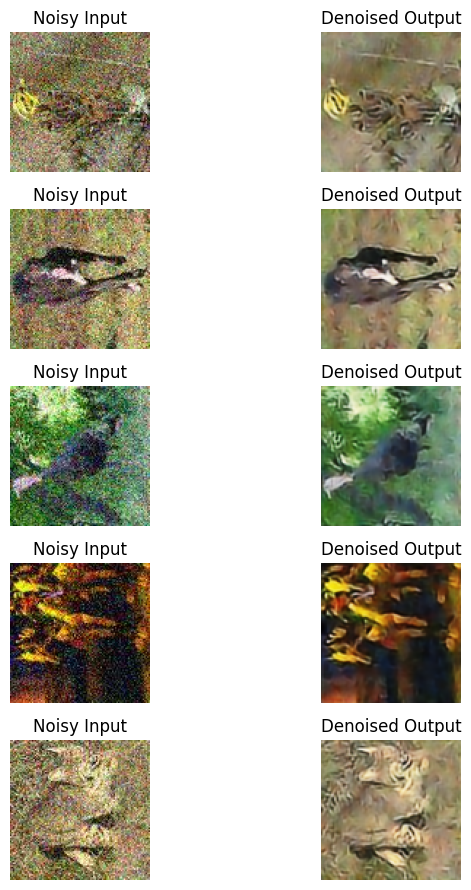

In [53]:
#@title denoising images {display-mode: "form"}

# load model
#model_url = base_url+'models/model_denoise_sharpen.keras'
#model_url = '/content/drive/MyDrive/autoencoder_demo/model_denoise_sharpen.keras'

model_dir = 'models/'
model_name = 'model_denoise_sharpen.keras'
model_url = base_url + model_dir + model_name

!wget {model_url} -O {model_name}
model = load_model(model_name)


show_denoising_results(model, x_test_noisy, x_test_clean, n=5)

### Reflection: Denoising and Copyright Risks
This demo shows how autoencoders can remove Gaussian noise and sharpen blurry images. However, similar techniques can also be used to remove watermarks, raising concerns about potential copyright infringement. While this model is not trained for that purpose, it's important to be aware of such risks when applying denoising methods.

To prevent misuse, researchers and platforms are exploring more robust watermarking (harder to remove without visible damage), AI-based watermark detectors (to flag tampered or suspicious images), and image provenance standards like C2PA metadata (to trace content origin and editing history).

At the same time, denoising has many positive and ethical applications—such as restoring old photos, enhancing medical images, and improving low-light photography—when used responsibly.

## Other usage of autoencoder

Beyond the image repair and compression tasks we've already shown, autoencoders are also used in several other practical ways. One is **anomaly detection** — that is, spotting something unusual or out of place. For example, if the model learns how to recreate images of everyday objects, it will likely struggle to recreate something very different, which can be a useful signal. This idea is used in fields like **fraud detection** or **early warnings in medical systems**. Another use is **feature extraction**, where the model learns to capture the essential structure of an image or document. These summaries can help organize large collections, group similar items, or support faster searches.

Basically, autoencoders serve as **a bridge** between classic pattern recognition and more advanced machine learning tasks. In the next module, we turn to large language models and the role of prompts — another way machines handle and reshape information. Later, we’ll also touch on generative tools, where autoencoder ideas resurface, serving as a starting point.

## Take-home Messages

* Autoencoders have the ability to "rebuild an image from itself". By analyzing what is happening under the hood, we found that autoencoders learned basic patterns such as object locations and textures, then reconstruct the image from these patterns.

* Autoencoders can reduce image size. Principal Component helps further enhancing storage efficiency for large image collections.

* Autoencoders can clean up noisy images

* Throughout this module, we only used a very simple model, yet it worked well across all tasks/

* Additionally, autoencoders support anomaly detection and feature extraction, as well as inspiring the starting of generative models.